<a href="https://colab.research.google.com/github/adithyarhm/sulfur-gas-concentration-forecasting/blob/main/TA_Nodes_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2><center><font color=#D40004><u> Sulfur Gas Conscentration Forecasting  </u></font></center></h2>
<h3><center> Adithya Rahman</center></h3>
<br>


# Goal of this Project
The primary goal of this project is to develop a robust model for forecasting sulfur gas concentration at Kawah Putih, Indonesia. By leveraging historical gas measurements and weather-related features collected around the crater area, the objective is to build an accurate prediction tool that supports real-time sulfur gas monitoring. Achieving this goal will strengthen the local early warning system for hazardous gas exposure, enhance situational awareness for visitors and authorities, and enable data-driven decisions for risk mitigation and evacuation planning. Ultimately, this predictive model aims to improve public safety, reduce health risks associated with sudden spikes in sulfur gas levels, and support more proactive environmental hazard management in the Kawah Putih region.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score
import xgboost as xgb

In [1]:
# 1. Mount Google Drive (kalau file disimpan di Drive)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/StasRG/TA/dataset/allnode.csv')
df.head()


,Node,GPS,Location,Weather,DateTime,H2S,SO2,Humidity,Temperature,WindsSpeed
0,1,"-7.166870, 107.401387",Dekat uap panas,Cerah,12/22/2025 11:53:00,43,149,87.03,17.94,1.44
1,1,"-7.166870, 107.401387",Dekat uap panas,Cerah,12/22/2025 11:53:02,40,149,87.03,17.94,0.72
2,1,"-7.166870, 107.401387",Dekat uap panas,Cerah,12/22/2025 11:53:04,40,149,87.23,17.94,0.72
3,1,"-7.166870, 107.401387",Dekat uap panas,Cerah,12/22/2025 11:53:06,40,141,87.23,17.94,0.72
4,1,"-7.166870, 107.401387",Dekat uap panas,Cerah,12/22/2025 11:53:08,40,133,87.23,17.93,0.72


# EDA (1)

## Parsing waktu dan tipe data

In [7]:
# Ubah DateTime ke datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Ekstrak fitur waktu untuk analisis
df['hour'] = df['DateTime'].dt.hour
df['minute'] = df['DateTime'].dt.minute
df['second'] = df['DateTime'].dt.second

# Pastikan kolom kategorikal bertipe category
cat_cols = ['Node', 'Location', 'Weather']
for c in cat_cols:
    df[c] = df[c].astype('category')

df.dtypes


,0
Node,category
GPS,object
Location,category
Weather,category
DateTime,datetime64[ns]
H2S,int64
SO2,int64
Humidity,float64
Temperature,float64
WindsSpeed,float64


## Cek missing value dan duplikasi

In [8]:
# Missing values per kolom
df.isna().sum()

# Persentase missing (kalau mau)
df.isna().mean() * 100

# Cek baris duplikat
df.duplicated().sum()

# (Opsional) hapus duplikat kalau memang tidak diinginkan
df = df.drop_duplicates()


## Distribusi dan statistik per fitur numerik

In [9]:
num_cols = ['H2S', 'SO2', 'Humidity', 'Temperature', 'WindsSpeed']
df[num_cols].describe()

# Statistik per Node
df.groupby('Node')[num_cols].describe().transpose()


/tmp/ipykernel_164/1651898409.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Node')[num_cols].describe().transpose()


Node                         1           2           3           4  \
H2S         count   739.000000  843.000000  247.000000  447.000000   
            mean    101.123139    6.754448  101.850202   28.906040   
            std      81.874200    3.742954   42.850917   15.212107   
            min      25.000000    1.000000   28.000000    4.000000   
            25%      49.000000    4.000000   62.500000   18.000000   
            50%      70.000000    7.000000  103.000000   25.000000   
            75%     116.000000    9.000000  133.000000   37.000000   
            max     435.000000   22.000000  203.000000   67.000000   
SO2         count   739.000000  843.000000  247.000000  447.000000   
            mean    276.569689    6.443654  453.639676   93.219239   
            std     194.681016   12.883180  178.720986   76.876065   
            min      68.000000    0.000000  110.000000    0.000000   
            25%     146.000000    0.000000  301.000000   35.000000   
            50%     209.000000    0.000000  466.000000   65.000000   
            75%     319.000000    7.000000  571.000000  144.000000   
            max    1027.000000   68.000000  948.000000  296.000000   
Humidity    count   739.000000  843.000000  247.000000  447.000000   
            mean     82.596671   79.063571   98.629150  100.000000   
            std       9.661798    2.947613    1.412398    0.000000   
            min      64.010000   74.380000   95.440000  100.000000   
            25%      73.570000   76.720000   97.400000  100.000000   
            50%      88.500000   78.230000   98.970000  100.000000   
            75%      90.100000   80.810000  100.000000  100.000000   
            max      94.430000   86.470000  100.000000  100.000000   
Temperature count   739.000000  843.000000  247.000000  447.000000   
            mean     19.624723   20.061708   17.249312   15.769262   
            std       2.203291    0.517738    0.396001    0.241180   
            min      17.450000   18.920000   16.510000   15.220000   
            25%      17.900000   19.645000   16.885000   15.580000   
            50%      18.160000   20.150000   17.400000   15.810000   
            75%      21.480000   20.500000   17.620000   15.960000   
            max      24.160000   20.940000   17.730000   16.180000   
WindsSpeed  count   739.000000  843.000000  247.000000  447.000000   
            mean      1.088281    0.319431    2.181862    1.735570   
            std       2.043896    0.921280    1.953291    1.099160   
            min       0.000000    0.000000    0.000000    0.360000   
            25%       0.000000    0.000000    0.360000    0.720000   
            50%       0.000000    0.000000    1.800000    1.440000   
            75%       1.440000    0.000000    3.960000    2.520000   
            max      10.800000    6.840000    6.840000    4.680000   

Node                        5           6  
H2S         count  452.000000  167.000000  
            mean    19.373894   14.149701  
            std     13.863271    4.940158  
            min      0.000000    4.000000  
            25%      9.000000   12.000000  
            50%     18.000000   15.000000  
            75%     25.000000   18.000000  
            max     61.000000   25.000000  
SO2         count  452.000000  167.000000  
            mean    97.172566  200.233533  
            std    103.852686   44.299630  
            min      0.000000   62.000000  
            25%      0.000000  201.000000  
            50%     68.000000  209.000000  
            75%    159.000000  220.000000  
            max    353.000000  259.000000  
Humidity    count  452.000000  167.000000  
            mean   100.000000  100.000000  
            std      0.000000    0.000000  
            min    100.000000  100.000000  
            25%    100.000000  100.000000  
            50%    100.000000  100.000000  
            75%    100.000000  100.000000  
            max    100.000000  100.000000  
Temperature count  452.000000

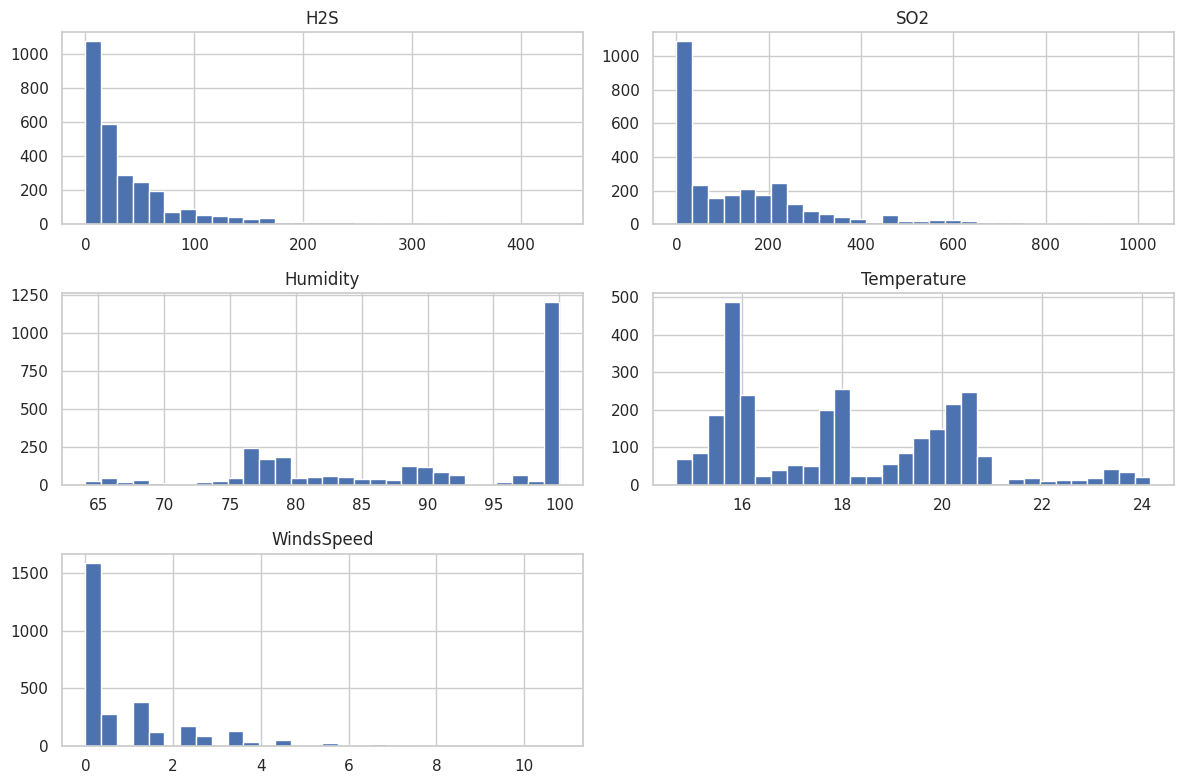

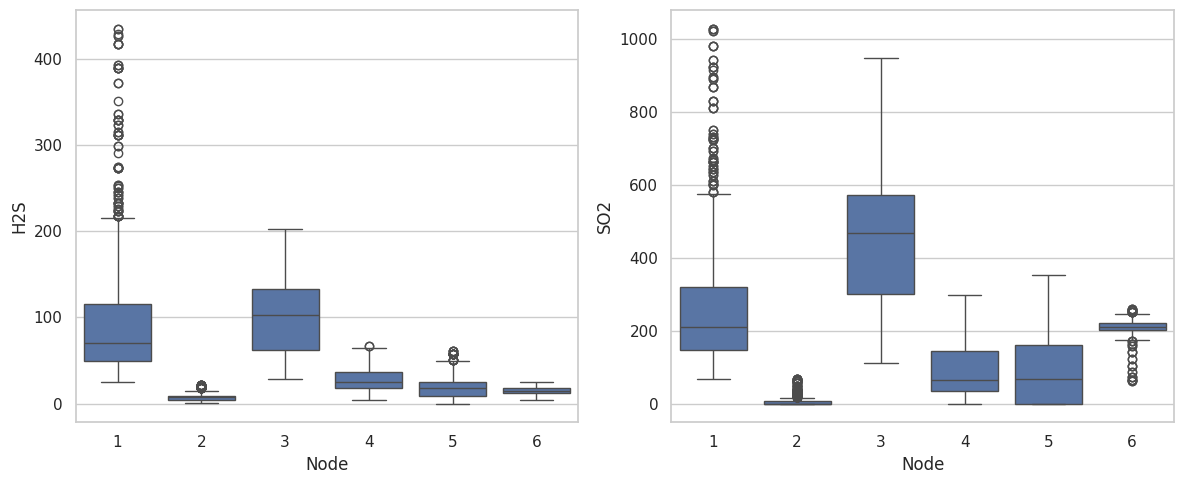

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', context='notebook')

# Histogram per fitur
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplot per Node untuk H2S dan SO2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Node', y='H2S')
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Node', y='SO2')
plt.tight_layout()
plt.show()


## Analisis kategorikal (Node, Location, Weather)

In [13]:
# Frekuensi Node, Location, Weather
print(df['Node'].value_counts())
print(df['Location'].value_counts())
print(df['Weather'].value_counts())


Node
2    843
1    739
5    452
4    447
3    247
6    167
Name: count, dtype: int64
Location
Dekat sumber mata air      843
Dekat uap panas            739
Goa                        452
Area Pengunjung            447
Hutan Mati                 247
Tangga Masuk Pengunjung    167
Name: count, dtype: int64
Weather
Hujan Kabut    1066
Mendung         874
Cerah           739
Hujan           149
Gerimis          67
Name: count, dtype: int64


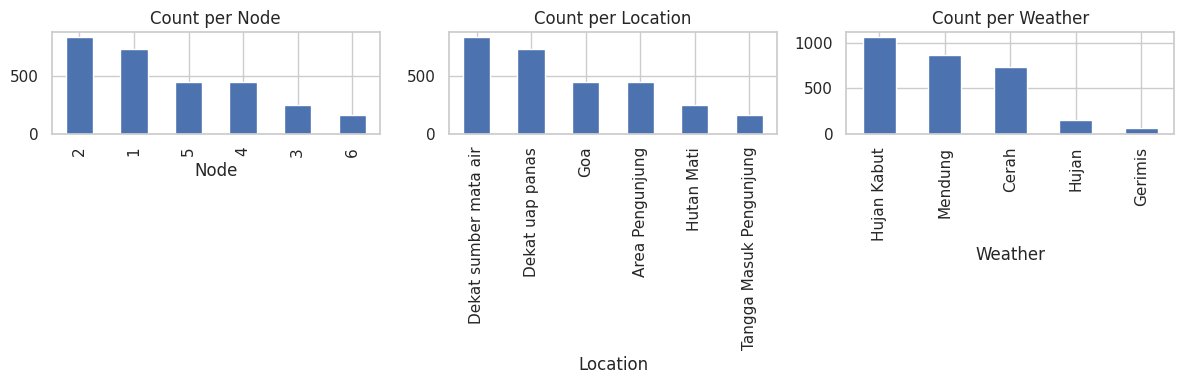

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
df['Node'].value_counts().plot(kind='bar'); plt.title('Count per Node')

plt.subplot(1, 3, 2)
df['Location'].value_counts().plot(kind='bar'); plt.title('Count per Location')

plt.subplot(1, 3, 3)
df['Weather'].value_counts().plot(kind='bar'); plt.title('Count per Weather')

plt.tight_layout()
plt.show()


## Analisis time-series per Node

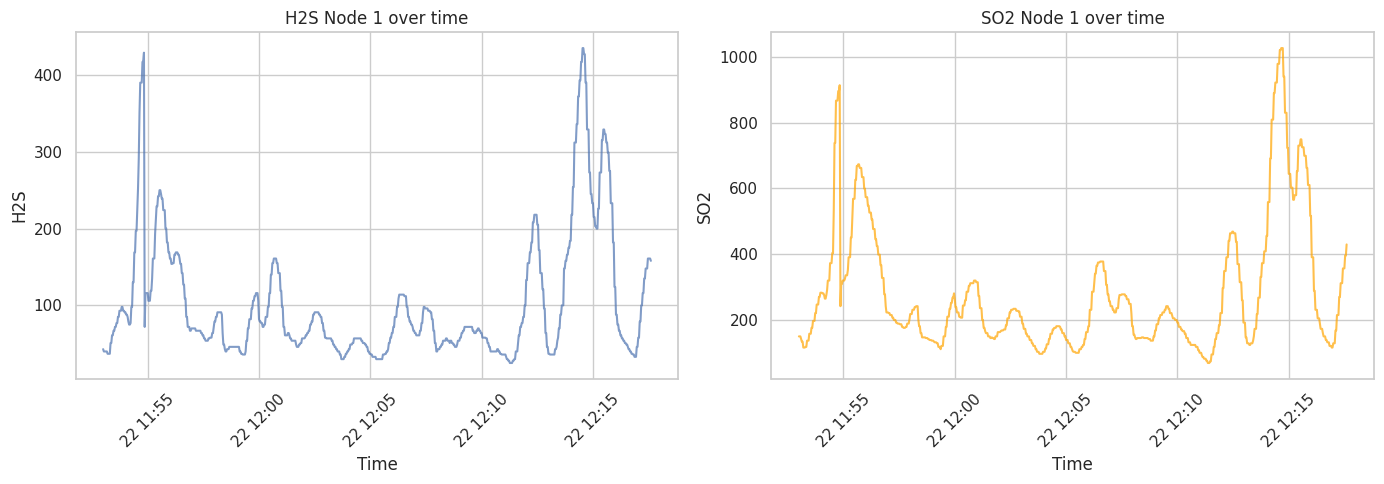

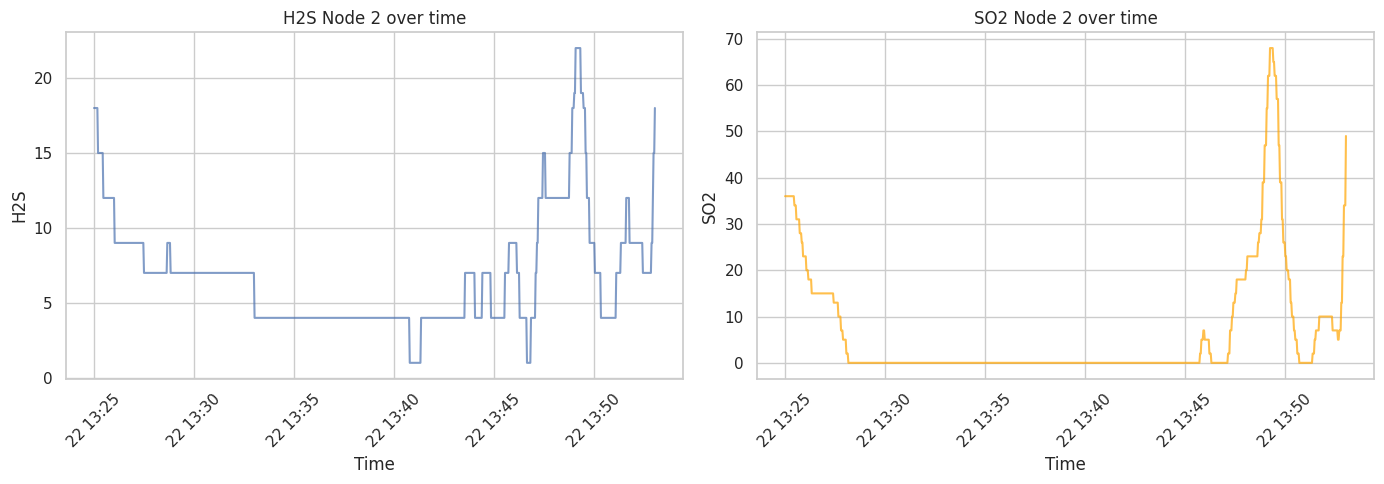

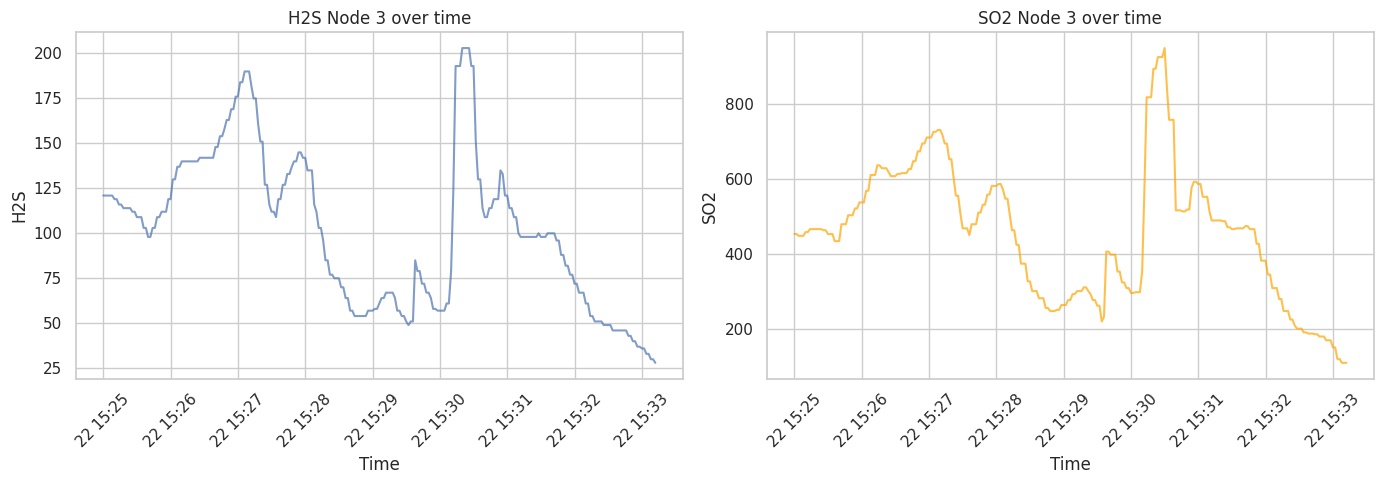

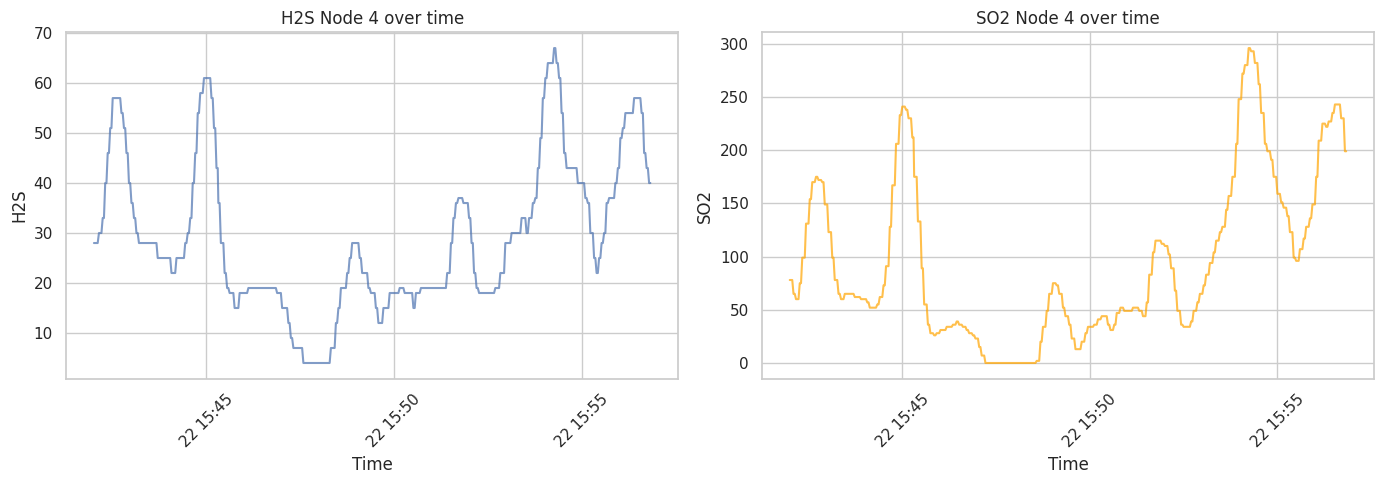

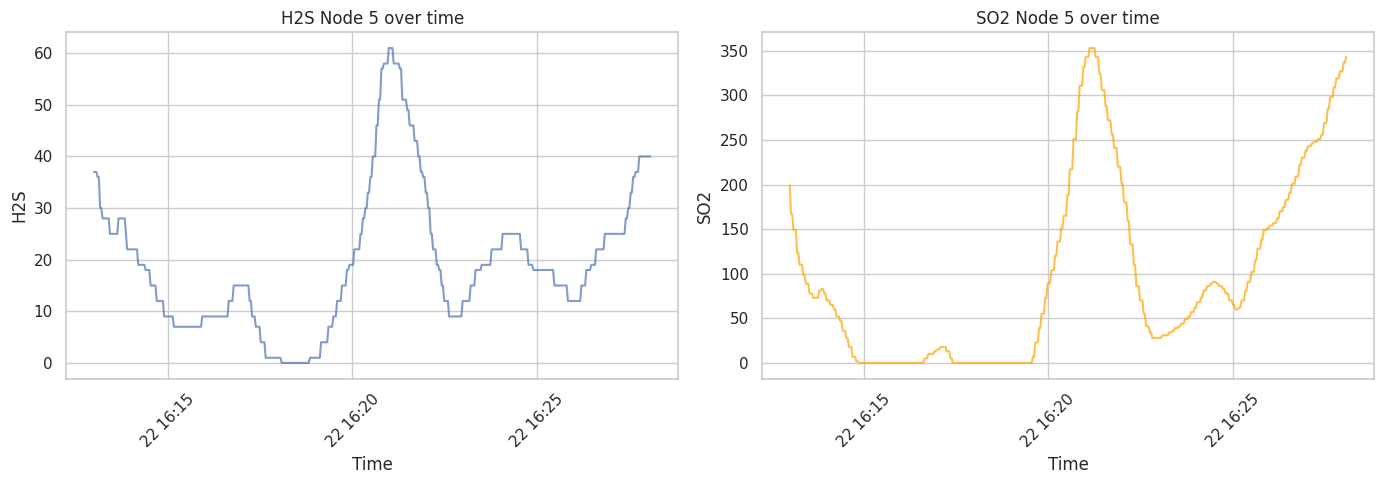

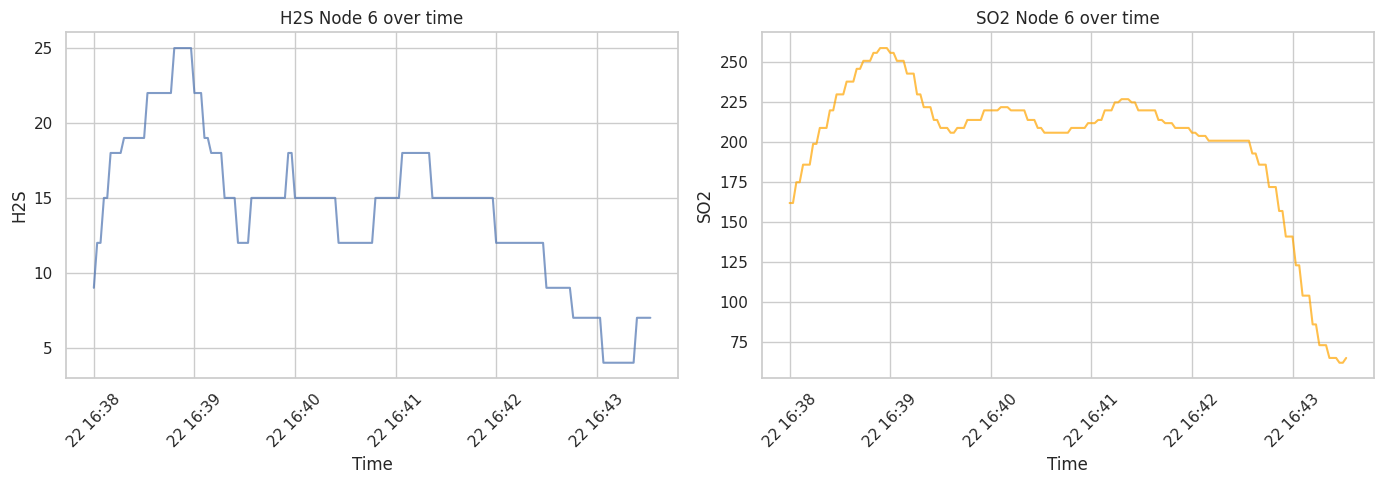

/tmp/ipykernel_164/4283676198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Node')[num_cols]


,Node,DateTime,H2S,SO2,Humidity,Temperature,WindsSpeed
0,1,2025-12-22 11:53:00,65.633333,174.933333,88.695667,17.820333,2.172
1,1,2025-12-22 11:54:00,193.900000,462.200000,91.373333,17.629000,6.120
2,1,2025-12-22 11:55:00,187.800000,520.733333,90.880333,17.952333,3.516
3,1,2025-12-22 11:56:00,130.866667,423.766667,89.160000,18.024667,1.068
4,1,2025-12-22 11:57:00,62.900000,193.966667,89.270000,17.890333,0.000


In [25]:
# Sort dulu
df = df.sort_values('DateTime')

# Plot H2S dan SO2 vs waktu, per Node
for node_id in df['Node'].unique():
    node_data = df[df['Node'] == node_id]

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(node_data['DateTime'], node_data['H2S'], alpha=0.7)
    plt.title(f'H2S Node {node_id} over time')
    plt.xlabel('Time')
    plt.ylabel('H2S')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    plt.plot(node_data['DateTime'], node_data['SO2'], alpha=0.7, color='orange')
    plt.title(f'SO2 Node {node_id} over time')
    plt.xlabel('Time')
    plt.ylabel('SO2')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Resample ke 1 menit (mean) per Node
df_resampled = (df.set_index('DateTime')
                  .groupby('Node')[num_cols]
                  .resample('1min')
                  .mean()
                  .reset_index())

df_resampled.head()

## Korelasi antar fitur numerik

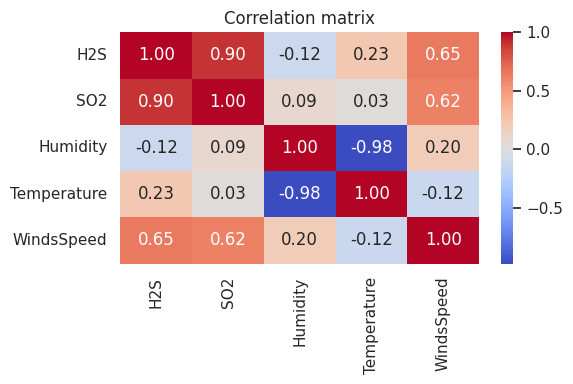

/tmp/ipykernel_164/3855393432.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr_per_node = df.groupby('Node')[num_cols].corr()


In [17]:
corr = df[num_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

# Korelasi per Node (opsional)
corr_per_node = df.groupby('Node')[num_cols].corr()
#corr_per_node


In [18]:
# Split GPS ke dua kolom numerik
df[['lat', 'lon']] = df['GPS'].str.replace('"', '', regex=False).str.split(',', expand=True)
df['lat'] = df['lat'].astype(float)
df['lon'] = df['lon'].astype(float)

df[['Node', 'Location', 'lat', 'lon']].drop_duplicates()


,Node,Location,lat,lon
0,1,Dekat uap panas,-7.166870,107.401387
739,2,Dekat sumber mata air,-7.167397,107.401775
1582,3,Hutan Mati,-7.167415,107.402914
1829,4,Area Pengunjung,-7.166614,107.403483
2276,5,Goa,-7.166418,107.404100
2728,6,Tangga Masuk Pengunjung,-7.166833,107.404111


## Analisis spasial sederhana (GPS)

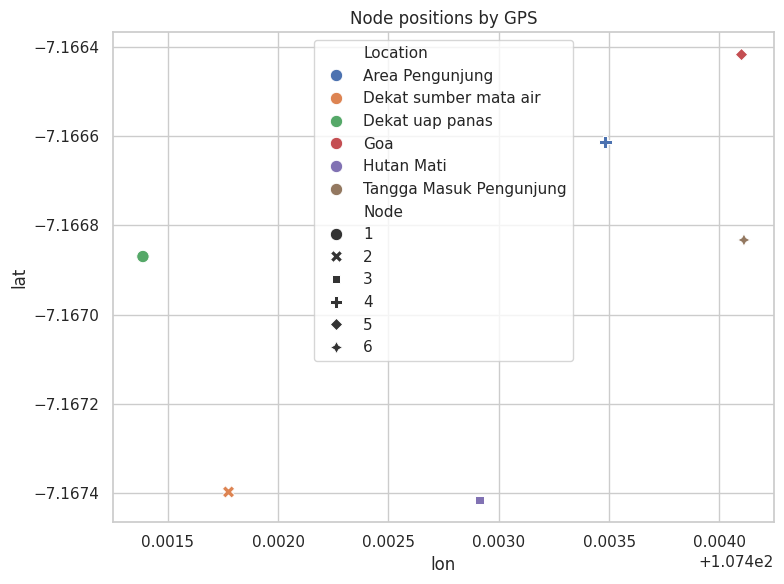

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.drop_duplicates(subset='Node'),
                x='lon', y='lat', hue='Location', style='Node', s=80)
plt.title('Node positions by GPS')
plt.tight_layout()
plt.show()


## Analisis per-kondisi (Weather/Location)

/tmp/ipykernel_164/998449253.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Weather')[num_cols].mean()
/tmp/ipykernel_164/998449253.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Location')[num_cols].mean()


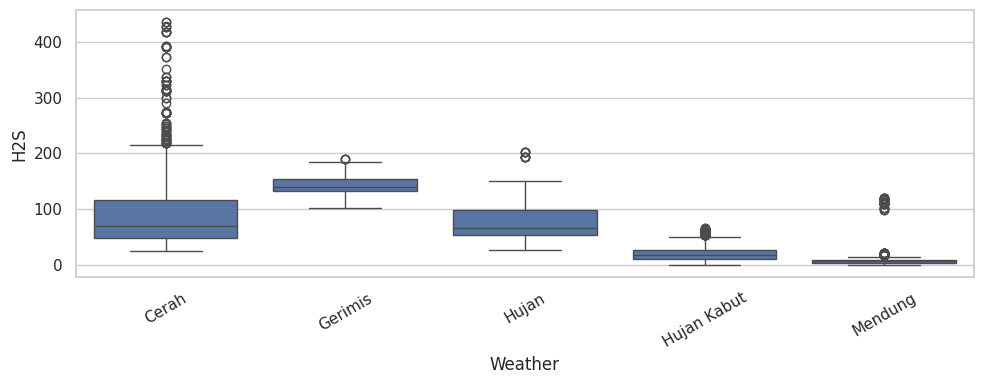

In [22]:
# Mean per Weather
df.groupby('Weather')[num_cols].mean()

# Mean per Location
df.groupby('Location')[num_cols].mean()

# Boxplot H2S per Weather
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Weather', y='H2S')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [24]:
# Simpan df yang sudah bersih + fitur waktu + lat/lon
df.to_csv('/content/drive/MyDrive/StasRG/TA/dataset/allnode_eda_clean.csv', index=False)

/tmp/ipykernel_164/1806779369.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_per_node = df.groupby('Node')[num_cols].describe()


# EDA (2)

## Persiapan dan fitur dasar per node

In [30]:
df = pd.read_csv('/content/drive/MyDrive/StasRG/TA/dataset/allnode.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')

cat_cols = ['Node', 'Location', 'Weather']
for c in cat_cols:
    df[c] = df[c].astype('category')

num_cols = ['H2S', 'SO2', 'Humidity', 'Temperature', 'WindsSpeed']


In [31]:
node_summary = df.groupby('Node').agg(
    n_obs=('H2S', 'size'),
    start_time=('DateTime', 'min'),
    end_time=('DateTime', 'max'),
    location=('Location', lambda x: x.mode()[0]),
    weather_mode=('Weather', lambda x: x.mode()[0])
).reset_index()

node_summary


/tmp/ipykernel_164/485109933.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  node_summary = df.groupby('Node').agg(


,Node,n_obs,start_time,end_time,location,weather_mode
0,1,739,2025-12-22 11:53:00,2025-12-22 12:17:36,Dekat uap panas,Cerah
1,2,843,2025-12-22 13:25:00,2025-12-22 13:53:04,Dekat sumber mata air,Mendung
2,3,247,2025-12-22 15:25:00,2025-12-22 15:33:12,Hutan Mati,Hujan
3,4,447,2025-12-22 15:42:00,2025-12-22 15:56:50,Area Pengunjung,Hujan Kabut
4,5,452,2025-12-22 16:13:00,2025-12-22 16:28:04,Goa,Hujan Kabut
5,6,167,2025-12-22 16:38:00,2025-12-22 16:43:32,Tangga Masuk Pengunjung,Hujan Kabut


## Statistik distribusi per node (profil tingkat gas)


In [32]:
stats_per_node = df.groupby('Node')[num_cols].describe().round(2)
stats_per_node


/tmp/ipykernel_164/4276464115.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_per_node = df.groupby('Node')[num_cols].describe().round(2)


H2S                                                    SO2          \
      count    mean    std   min   25%    50%    75%    max  count    mean   
Node                                                                         
1     739.0  101.12  81.87  25.0  49.0   70.0  116.0  435.0  739.0  276.57   
2     843.0    6.75   3.74   1.0   4.0    7.0    9.0   22.0  843.0    6.44   
3     247.0  101.85  42.85  28.0  62.5  103.0  133.0  203.0  247.0  453.64   
4     447.0   28.91  15.21   4.0  18.0   25.0   37.0   67.0  447.0   93.22   
5     452.0   19.37  13.86   0.0   9.0   18.0   25.0   61.0  452.0   97.17   
6     167.0   14.15   4.94   4.0  12.0   15.0   18.0   25.0  167.0  200.23   

      ... Temperature        WindsSpeed                                      \
      ...         75%    max      count  mean   std   min   25%   50%   75%   
Node  ...                                                                     
1     ...       21.48  24.16      739.0  1.09  2.04  0.00  0.00  0.00  1.44   
2     ...       20.50  20.94      843.0  0.32  0.92  0.00  0.00  0.00  0.00   
3     ...       17.62  17.73      247.0  2.18  1.95  0.00  0.36  1.80  3.96   
4     ...       15.96  16.18      447.0  1.74  1.10  0.36  0.72  1.44  2.52   
5     ...       15.96  16.14      452.0  0.94  0.90  0.00  0.00  0.72  1.44   
6     ...       15.30  15.60      167.0  0.53  0.34  0.00  0.36  0.72  0.72   

             
        max  
Node         
1     10.80  
2      6.84  
3      6.84  
4      4.68  
5      3.60  
6      1.08  

[6 rows x 40 columns]

In [33]:
node_mean = df.groupby('Node')[['H2S', 'SO2']].mean().round(2)
node_std  = df.groupby('Node')[['H2S', 'SO2']].std().round(2)
node_min  = df.groupby('Node')[['H2S', 'SO2']].min()
node_max  = df.groupby('Node')[['H2S', 'SO2']].max()

summary_table = pd.concat(
    {'mean': node_mean, 'std': node_std, 'min': node_min, 'max': node_max},
    axis=1
)
summary_table


/tmp/ipykernel_164/2055305680.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  node_mean = df.groupby('Node')[['H2S', 'SO2']].mean().round(2)
/tmp/ipykernel_164/2055305680.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  node_std  = df.groupby('Node')[['H2S', 'SO2']].std().round(2)
/tmp/ipykernel_164/2055305680.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  node_min  = df.groupby('Node')[['H2S', 'SO2']].min()


mean            std         min       max      
         H2S     SO2    H2S     SO2 H2S  SO2  H2S   SO2
Node                                                   
1     101.12  276.57  81.87  194.68  25   68  435  1027
2       6.75    6.44   3.74   12.88   1    0   22    68
3     101.85  453.64  42.85  178.72  28  110  203   948
4      28.91   93.22  15.21   76.88   4    0   67   296
5      19.37   97.17  13.86  103.85   0    0   61   353
6      14.15  200.23   4.94   44.30   4   62   25   259

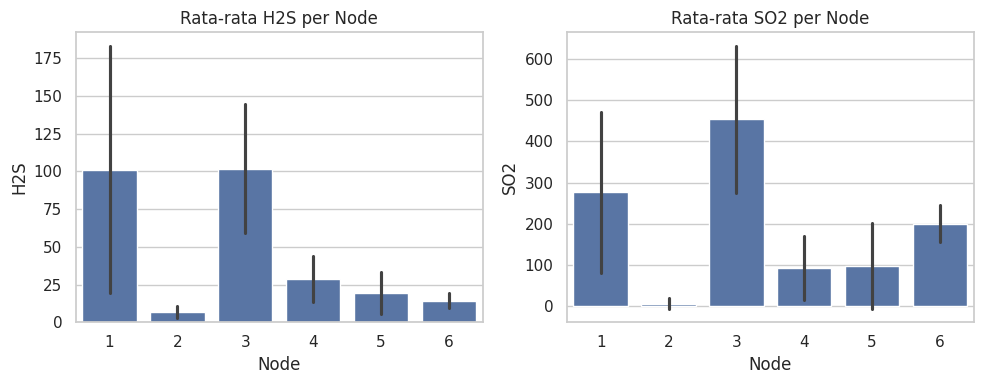

In [34]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(data=df, x='Node', y='H2S', estimator=np.mean, errorbar='sd')
plt.title('Rata-rata H2S per Node')

plt.subplot(1,2,2)
sns.barplot(data=df, x='Node', y='SO2', estimator=np.mean, errorbar='sd')
plt.title('Rata-rata SO2 per Node')

plt.tight_layout()
plt.show()


## Dinamika time-series per node (stabilitas vs spike)


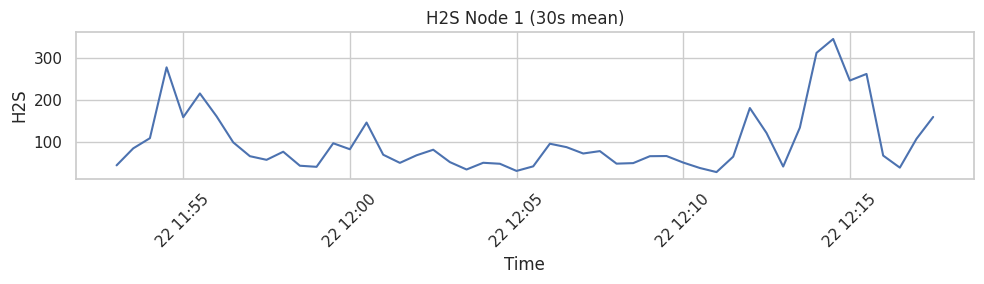

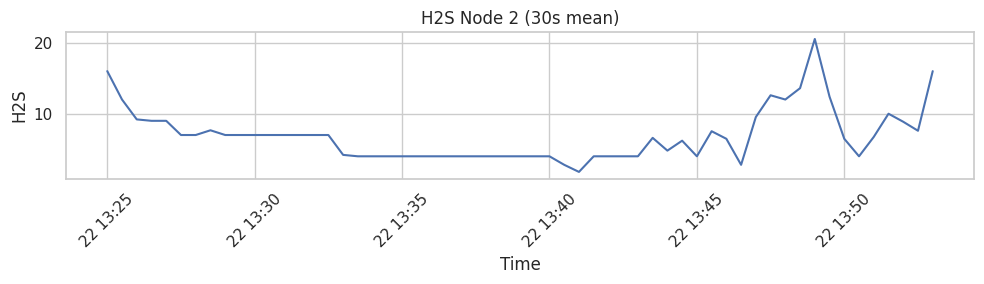

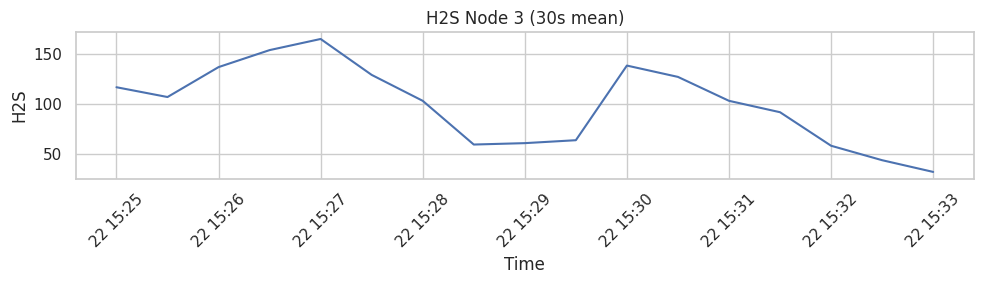

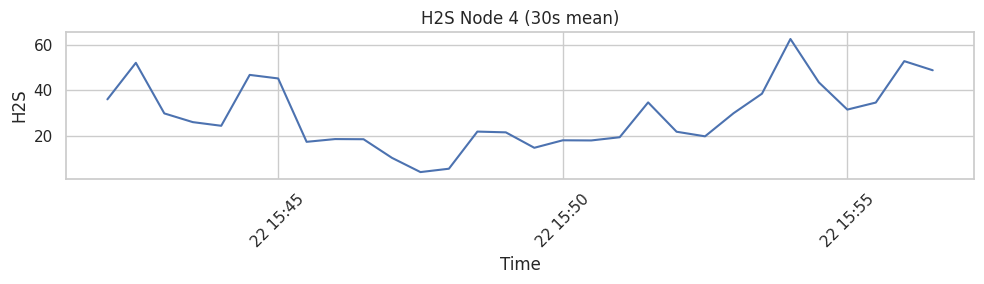

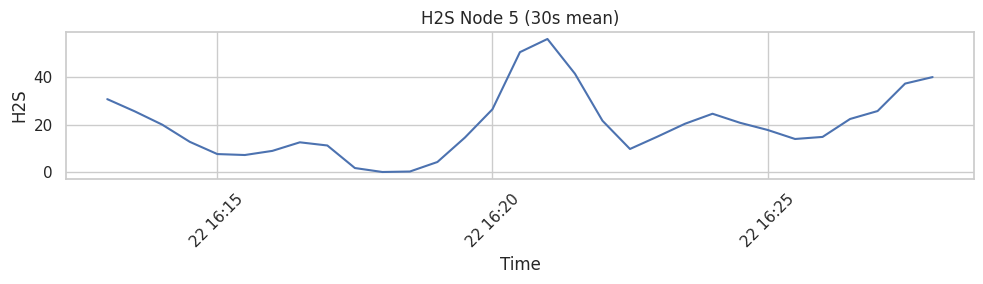

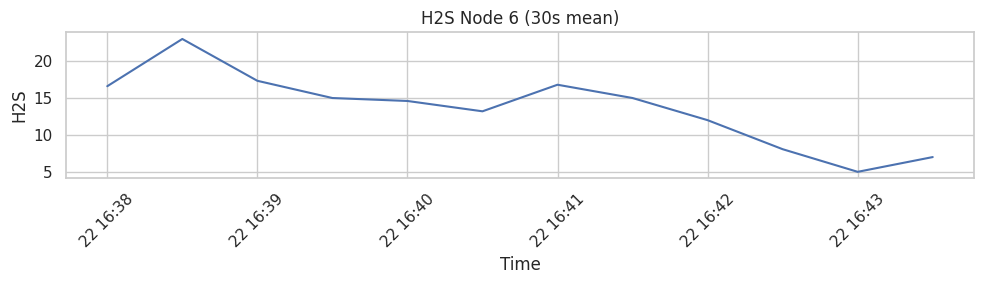

In [35]:
def plot_ts_node(node_id, var='H2S', window='30s'):
    data = df[df['Node'] == node_id].set_index('DateTime').sort_index()
    # Resample ringan biar plot lebih smooth
    res = data[var].resample(window).mean()

    plt.figure(figsize=(10,3))
    plt.plot(res.index, res.values)
    plt.title(f'{var} Node {node_id} ({window} mean)')
    plt.ylabel(var); plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for nid in sorted(df['Node'].unique()):
    plot_ts_node(nid, var='H2S', window='30s')


## Hubungan fitur lingkungan per node


In [36]:
# Korelasi global per node
corr_per_node = df.groupby('Node')[num_cols].corr()

# Contoh akses korelasi Node 1
corr_node1 = corr_per_node.loc[1]
corr_node1


/tmp/ipykernel_164/216795481.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr_per_node = df.groupby('Node')[num_cols].corr()


,H2S,SO2,Humidity,Temperature,WindsSpeed
H2S,1.000000,0.962930,-0.256006,0.325825,0.833530
SO2,0.962930,1.000000,-0.250777,0.318305,0.774731
Humidity,-0.256006,-0.250777,1.000000,-0.990749,-0.065321
Temperature,0.325825,0.318305,-0.990749,1.000000,0.116639
WindsSpeed,0.833530,0.774731,-0.065321,0.116639,1.000000


## Konteks lokasi dan cuaca per node


In [38]:
loc_weather_node = df.groupby(['Node', 'Location', 'Weather'])[num_cols].mean().round(2)
loc_weather_node


/tmp/ipykernel_164/1674906712.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_weather_node = df.groupby(['Node', 'Location', 'Weather'])[num_cols].mean().round(2)


H2S     SO2  Humidity  \
Node Location                Weather                                
1    Area Pengunjung         Cerah          NaN     NaN       NaN   
                             Gerimis        NaN     NaN       NaN   
                             Hujan          NaN     NaN       NaN   
                             Hujan Kabut    NaN     NaN       NaN   
                             Mendung        NaN     NaN       NaN   
...                                         ...     ...       ...   
6    Tangga Masuk Pengunjung Cerah          NaN     NaN       NaN   
                             Gerimis        NaN     NaN       NaN   
                             Hujan          NaN     NaN       NaN   
                             Hujan Kabut  14.15  200.23     100.0   
                             Mendung        NaN     NaN       NaN   

                                          Temperature  WindsSpeed  
Node Location                Weather                               
1    Area Pengunjung         Cerah                NaN         NaN  
                             Gerimis              NaN         NaN  
                             Hujan                NaN         NaN  
                             Hujan Kabut          NaN         NaN  
                             Mendung              NaN         NaN  
...                                               ...         ...  
6    Tangga Masuk Pengunjung Cerah                NaN         NaN  
                             Gerimis              NaN         NaN  
                             Hujan                NaN         NaN  
                             Hujan Kabut        15.09        0.53  
                             Mendung              NaN         NaN  

[180 rows x 5 columns]

## Ringkas insight per node untuk desain task ML


In [39]:
def summarize_node(df, node_id):
    d = df[df['Node'] == node_id]
    return {
        'Node': node_id,
        'Location': d['Location'].mode()[0],
        'Weather_mode': d['Weather'].mode()[0],
        'n_obs': len(d),
        'H2S_mean': d['H2S'].mean(),
        'H2S_max': d['H2S'].max(),
        'SO2_mean': d['SO2'].mean(),
        'SO2_max': d['SO2'].max(),
        'Humidity_mean': d['Humidity'].mean(),
        'Temp_mean': d['Temperature'].mean(),
        'Wind_mean': d['WindsSpeed'].mean()
    }

summary_nodes = pd.DataFrame([summarize_node(df, nid) for nid in df['Node'].unique()])
summary_nodes


,Node,Location,Weather_mode,n_obs,H2S_mean,H2S_max,SO2_mean,SO2_max,Humidity_mean,Temp_mean,Wind_mean
0,1,Dekat uap panas,Cerah,739,101.123139,435,276.569689,1027,82.596671,19.624723,1.088281
1,2,Dekat sumber mata air,Mendung,843,6.754448,22,6.443654,68,79.063571,20.061708,0.319431
2,3,Hutan Mati,Hujan,247,101.850202,203,453.639676,948,98.629150,17.249312,2.181862
3,4,Area Pengunjung,Hujan Kabut,447,28.906040,67,93.219239,296,100.000000,15.769262,1.735570
4,5,Goa,Hujan Kabut,452,19.373894,61,97.172566,353,100.000000,15.884159,0.939027
5,6,Tangga Masuk Pengunjung,Hujan Kabut,167,14.149701,25,200.233533,259,100.000000,15.091677,0.534611
